In [1]:
import pandas as pd
import numpy as np
import os
import numpy as np
import precession.eccentricity as prececc
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import cumtrapz

In [2]:
#function to save a simulation

def archive_bbh_simulation(mass_ratio, chi1, chi2, theta1_0, theta2_0, dphi_0, raw_data, folder="bbh_simulations_archive"):
    
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    time = raw_data['t'].flatten()
    separation = raw_data['a'].flatten()
    th1_rad = raw_data['theta1'].flatten()
    th2_rad = raw_data['theta2'].flatten()
    dphi_rad = raw_data['deltaphi'].flatten()

    m1 = 1.0 / (1.0 + mass_ratio)
    m2 = mass_ratio / (1.0 + mass_ratio)
    
    eff_spin = (m1 * chi1 * np.cos(th1_rad) + m2 * chi2 * np.cos(th2_rad))
    
    reduced_mass = (m1 * m2) 
    l_magnitude = reduced_mass * np.sqrt(separation)
    
    df = pd.DataFrame({
        'time_M': time,
        'separation_M': separation,
        'angular_momentum_L': l_magnitude,
        'effective_spin_chi_eff': eff_spin,
        'theta1_rad': th1_rad,
        'theta2_rad': th2_rad,
        'deltaphi_rad': dphi_rad
    })
    
    th1_deg = int(np.degrees(theta1_0))
    th2_deg = int(np.degrees(theta2_0))
    dp_deg = int(np.degrees(dphi_0))
    

    filename = (f"BBH_q={mass_ratio:.2f}_chi1={chi1:.2f}_chi2={chi2:.2f}_"
                f"th1={th1_deg}_th2={th2_deg}_dphi={dp_deg}.csv")
    filepath = os.path.join(folder, filename)
    
    header = (f"# BBH Simulation Data \n"
              f"# Initial Conditions: q={mass_ratio}, chi1={chi1}, chi2={chi2}, "
              f"theta1_0_deg={th1_deg}, theta2_0_deg={th2_deg}, deltaphi_0_deg={dp_deg}\n")
    
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(header)
        df.to_csv(f, index=False, float_format='%.16e')

In [3]:
q = 0.9
chi1_0 = 0.8
chi2_0 = 0.5
th1_0 = np.pi / 4 
th2_0 = np.pi / 6
dp_0  = np.pi / 2  

a_grid = np.geomspace(100.0, 10.0, 10000)

raw_data = prececc.inspiral_orbav(
    q=q, chi1=chi1_0, chi2=chi2_0,
    theta1=th1_0, theta2=th2_0, deltaphi=dp_0,
    a=a_grid, e=0.0
)

t_M = raw_data['t'].flatten()
a_M = raw_data['a'].flatten()
theta1_rad = raw_data['theta1'].flatten()
theta2_rad = raw_data['theta2'].flatten()
deltaphi_rad = raw_data['deltaphi'].flatten()


m1 = 1.0 / (1.0 + q) 
m2 = q / (1.0 + q)   

chi_eff = (m1 * chi1_0 * np.cos(theta1_rad) + m2 * chi2_0 * np.cos(theta2_rad))

L_orbital = (m1 * m2) * np.sqrt(a_M)

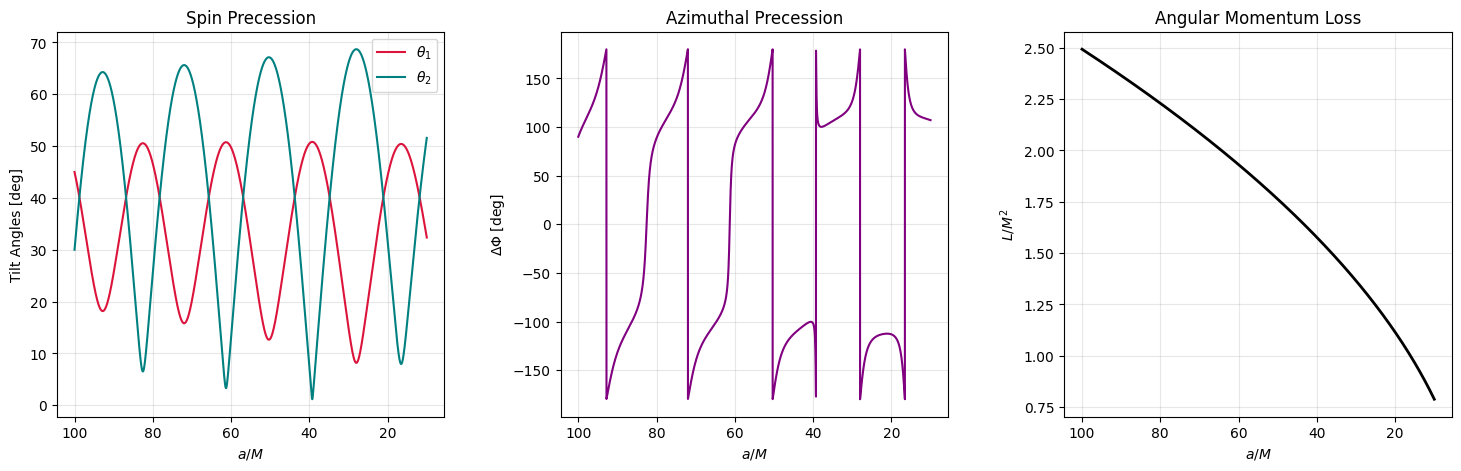

In [19]:
#graphs (rad --> degrees)


fig, axs = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3)

# 1. Spin evolution
axs[0].plot(a_M, np.degrees(theta1_rad), label=r'$\theta_1$', color='crimson', lw=1.5)
axs[0].plot(a_M, np.degrees(theta2_rad), label=r'$\theta_2$', color='teal', lw=1.5)
axs[0].set_xlabel(r'$a/M$')
axs[0].set_ylabel(r'Tilt Angles [deg]')
axs[0].set_title('Spin Precession')
axs[0].invert_xaxis()
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# 2. deltaphi evolution
axs[1].plot(a_M, np.degrees(deltaphi_rad), color='purple', lw=1.5)
axs[1].set_xlabel(r'$a/M$')
axs[1].set_ylabel(r'$\Delta\Phi$ [deg]')
axs[1].set_title('Azimuthal Precession')
axs[1].invert_xaxis()
axs[1].grid(True, alpha=0.3)

# 3. L evolution
axs[2].plot(a_M, L_orbital, color='black', lw=2)
axs[2].set_xlabel(r'$a/M$')
axs[2].set_ylabel(r'$L/M^2$')
axs[2].set_title('Angular Momentum Loss')
axs[2].invert_xaxis()
axs[2].grid(True, alpha=0.3)

plt.show()

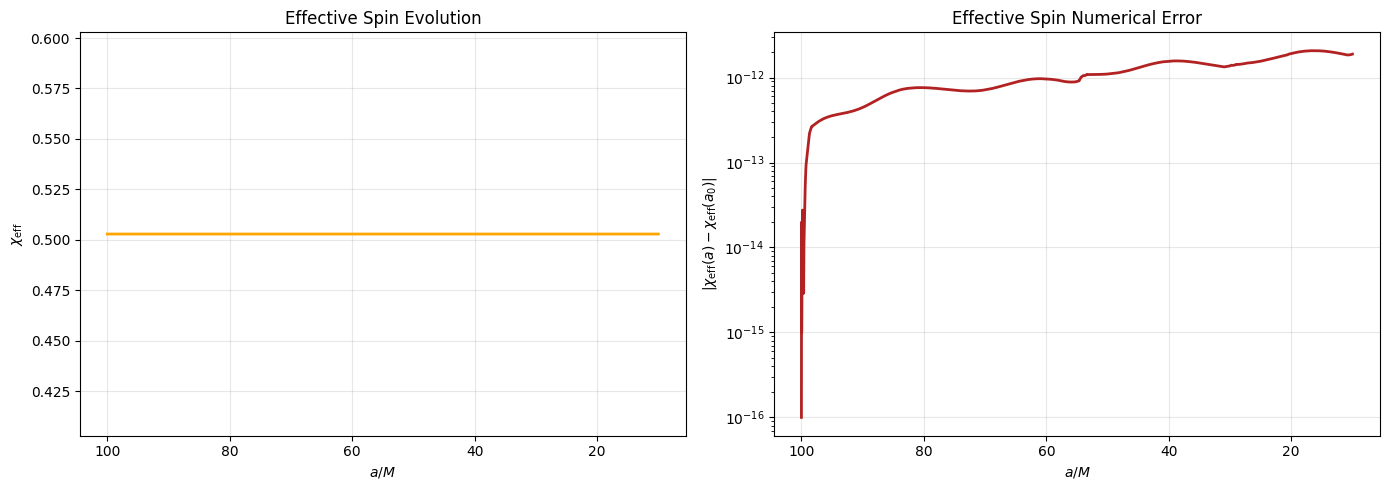

In [20]:
#chi eff graph

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(a_M, chi_eff, color='orange', lw=2)

base_value = chi_eff[0]
ax1.set_ylim(base_value - 0.1, base_value + 0.1) 
ax1.set_xlabel(r'$a/M$')
ax1.set_ylabel(r'$\chi_{\mathrm{eff}}$')
ax1.set_title('Effective Spin Evolution')
ax1.invert_xaxis()
ax1.grid(True, alpha=0.3)


chi_eff_error = np.abs(chi_eff - chi_eff[0])
chi_eff_error = np.where(chi_eff_error == 0, 1e-16, chi_eff_error)
ax2.plot(a_M, chi_eff_error, color='firebrick', lw=2)
ax2.set_yscale('log') 
ax2.set_xlabel(r'$a/M$')
ax2.set_ylabel(r'$|\chi_{\mathrm{eff}}(a) - \chi_{\mathrm{eff}}(a_0)|$')
ax2.set_title('Effective Spin Numerical Error')
ax2.invert_xaxis()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

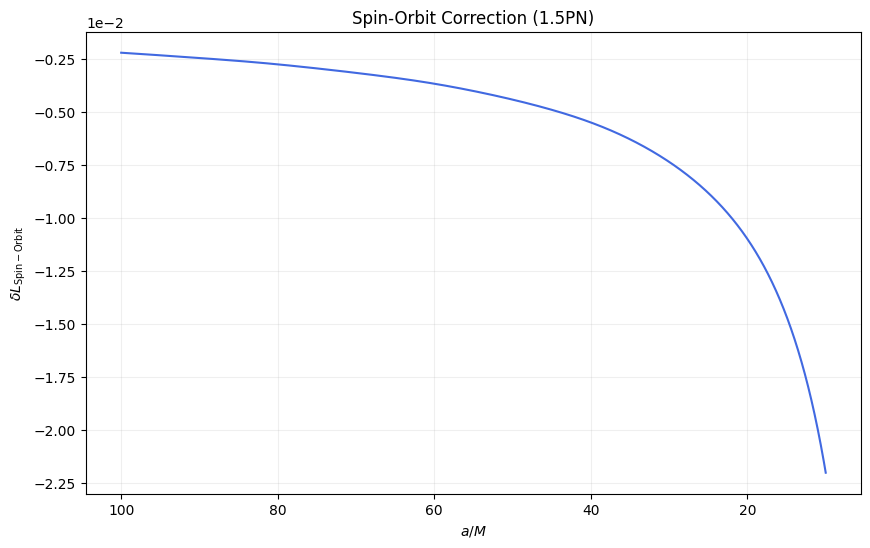

In [26]:
# spin-orbit correction (1.5 PN)

s1_mag = m1**2 * chi1_0
s2_mag = m2**2 * chi2_0

S1_L = s1_mag * np.cos(theta1_rad)
S2_L = s2_mag * np.cos(theta2_rad)
S_tot_L = S1_L + S2_L

cos_gamma = (np.sin(theta1_rad) * np.sin(theta2_rad) * np.cos(deltaphi_rad) + 
             np.cos(theta1_rad) * np.cos(theta2_rad))
s_tot_mag = np.sqrt(s1_mag**2 + s2_mag**2 + 2 * s1_mag * s2_mag * cos_gamma)

v = 1.0 / np.sqrt(a_M)
eta = m1 * m2 

L_1PN = L_orbital * (0.5 * (3.0 + eta) * v**2)

c1 = 4.0 + 3.0 * (m2 / m1)
c2 = 4.0 + 3.0 * (m1 / m2)
S_eff_SO = (c1 * S1_L) + (c2 * S2_L)

L_15PN_SO = L_orbital * (-0.5 * S_eff_SO * v**3)

L_corrected = L_orbital + L_1PN + L_15PN_SO

J_mag = np.sqrt(L_corrected**2 + s_tot_mag**2 + 2 * L_corrected * S_tot_L)

L_residual = L_15PN_SO

plt.figure(figsize=(10, 6))
plt.plot(a_M, L_residual, color='royalblue', lw=1.5)
plt.xlabel(r'$a/M$')
plt.ylabel(r'$\delta L_{\mathrm{Spin-Orbit}}$') 
plt.title('Spin-Orbit Correction (1.5PN)')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.gca().invert_xaxis() 
plt.grid(True, alpha=0.2)
plt.show()

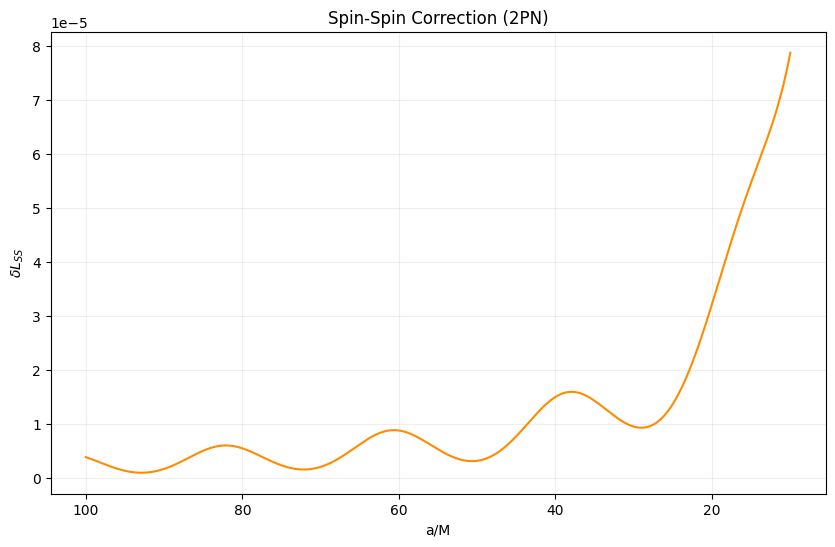

In [22]:
# Spin-Spin correction (2PN)

L_SS_correction = L_orbital * ( (s1_mag * s2_mag * cos_gamma) / (a_M**2) )

plt.figure(figsize=(10, 6))
plt.plot(a_M, L_SS_correction, color='darkorange', lw=1.5)
plt.xlabel('a/M')
plt.ylabel(r'$\delta L_{SS}$')
plt.title('Spin-Spin Correction (2PN)')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.2)
plt.show()

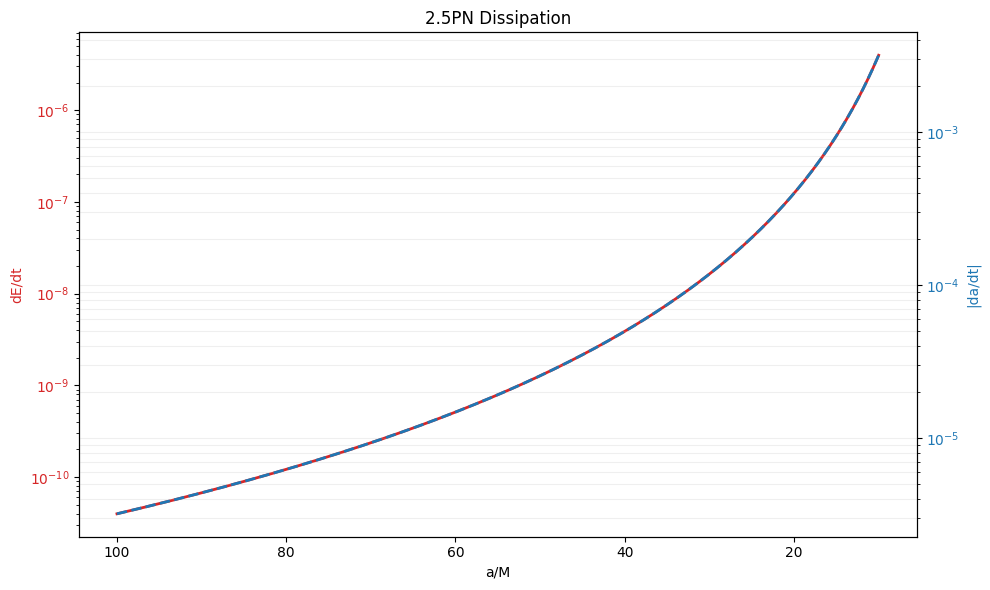

In [23]:
# 2.5PN dissipation

nu = (m1 * m2) / (m1 + m2)**2 
energy_flux = (32/5) * (nu**2) * (1/a_M)**5
da_dt = -(64/5) * nu * (1/a_M)**3


fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:red'
ax1.set_xlabel('a/M')
ax1.set_ylabel('dE/dt', color=color)
ax1.plot(a_M, energy_flux, color=color, lw=2, label='GW Luminosity')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log') 
ax2 = ax1.twinx() 
color = 'tab:blue'
ax2.set_ylabel('|da/dt|', color=color)
ax2.plot(a_M, np.abs(da_dt), color=color, lw=2, ls='--', label='Inspiral Velocity')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')
plt.title('2.5PN Dissipation')
plt.gca().invert_xaxis()
plt.grid(True, which="both", alpha=0.2)
fig.tight_layout()
plt.show()

In [5]:
#multiple simulations

mass_ratios = [0.3]
chi1_values = [0.6]

chi2_const = 0.7
th1_0 = np.pi / 4 
th2_0 = np.pi / 4
dp_0  = np.pi / 2  

a_grid = np.geomspace(100.0, 1.0, 10000)

for q in mass_ratios:
    
    if q > 1.0:
        raise ValueError(f"q deve essere <= 1.")

    for x1 in chi1_values:
        
        raw_data = prececc.inspiral_orbav(
            q=q, chi1=x1, chi2=chi2_const,
            theta1=th1_0, theta2=th2_0, deltaphi=dp_0,
            a=a_grid, e=0.0
        )
        
        # 3. ARCHIVIAZIONE
        archive_bbh_simulation(
            mass_ratio=q, 
            chi1=x1, 
            chi2=chi2_const, 
            theta1_0=th1_0, 
            theta2_0=th2_0, 
            dphi_0=dp_0, 
            raw_data=raw_data
        )

print("All simulations completed and archived.")

All simulations completed and archived.


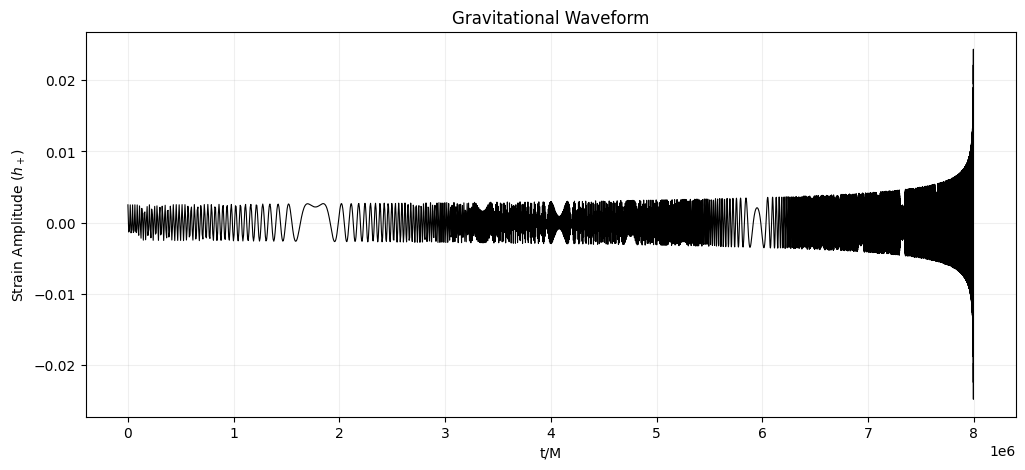

In [24]:
omega_orb = np.sqrt(1.0 / a_M**3) 

gw_phase = 2 * cumtrapz(omega_orb, t_M, initial=0)

h_envelope = (m1 * m2) / a_M

h_plus = h_envelope * np.cos(gw_phase)


plt.figure(figsize=(12, 5))
plt.plot(t_M, h_plus, color='black', lw=0.8)
plt.xlabel('t/M')
plt.ylabel('Strain Amplitude ($h_+$)')
plt.title('Gravitational Waveform')
plt.grid(alpha=0.2)
#plt.xlim(t_M.max() - 5000, t_M.max()) 
plt.show()